In [93]:
import pandas as pd
import numpy as np 
import os
import pytz
import pandas_market_calendars as mcal
from datetime import time
import yfinance as yf

In [94]:
# Carpeta donde están tus CSV
carpeta = "Datos/Originales/DowJones"

# Lista todos los archivos CSV en la carpeta
archivos = [f for f in os.listdir(carpeta) if f.endswith('.csv')]

lista_dfs = []

for i, archivo in enumerate(archivos):
    ruta_completa = os.path.join(carpeta, archivo)
    #globals()[f'df{i}'] = pd.read_csv(ruta_completa)
    lista_dfs.append(pd.read_csv(ruta_completa))

In [95]:
# ==============================
# 3️⃣ Reasignar registros fuera del rango horario
# ==============================
def assign_trading_day(ts):
    local_time = ts.time()
    date = ts.date()

    if local_time < MARKET_OPEN:
        # Antes de la apertura → se asigna al día anterior
        new_date = pd.Timestamp(date) - pd.Timedelta(days=1)
    elif local_time > MARKET_CLOSE:
        # Después del cierre → se asigna al día siguiente
        new_date = pd.Timestamp(date) + pd.Timedelta(days=1)
    else:
        new_date = pd.Timestamp(date)

    return new_date

In [96]:
for df in lista_dfs:
    df.sort_values('date',inplace=True)

    # Rango horario del NYSE
    MARKET_OPEN = time(9, 30)
    MARKET_CLOSE = time(16, 30)

    # Calendario oficial NYSE
    nyse = mcal.get_calendar("NYSE")
    valid_days = nyse.valid_days(start_date="2000-01-01", end_date="2030-12-31")

    # Convertir la columna 'date' a datetime con zona UTC
    df["date"] = pd.to_datetime(df["date"], utc=True)

    # ==============================
    # 2️⃣ Convertir a horario Nueva York
    # ==============================
    df["date_ny"] = df["date"].dt.tz_convert("America/New_York")

    # ==============================
    # 3️⃣ Reasignar registros fuera del rango horario
    # ==============================

    df["trading_day"] = df["date_ny"].apply(assign_trading_day)

    # ==============================
    # 4️⃣ Eliminar días no hábiles del NYSE
    # ==============================
    # Convertir los días válidos del NYSE a zona NY
    valid_days = pd.DatetimeIndex(valid_days.tz_convert("America/New_York")).normalize()
    df["trading_day"] = pd.to_datetime(df["trading_day"]).dt.tz_localize("America/New_York").dt.floor('D')

    # Filtrar solo días hábiles
    df = df[df["trading_day"].isin(valid_days)].copy()
    
    lista_dfs[i] = df

In [97]:
lista_dfs[0].head()

,open,high,low,last,close,volume,date,symbol,exchange,date_ny,trading_day
722,193.63,193.920,192.96,NaN,193.000,NaN,2018-06-06 17:30:00+00:00,AAPL,IEXG,2018-06-06 13:30:00-04:00,2018-06-06 00:00:00-04:00
721,192.98,193.040,191.95,NaN,192.405,NaN,2018-06-06 18:00:00+00:00,AAPL,IEXG,2018-06-06 14:00:00-04:00,2018-06-06 00:00:00-04:00
720,192.72,192.765,191.95,NaN,192.405,NaN,2018-06-06 18:30:00+00:00,AAPL,IEXG,2018-06-06 14:30:00-04:00,2018-06-06 00:00:00-04:00
719,192.44,193.260,192.43,NaN,193.070,NaN,2018-06-06 19:00:00+00:00,AAPL,IEXG,2018-06-06 15:00:00-04:00,2018-06-06 00:00:00-04:00
718,193.17,193.260,192.77,NaN,193.070,NaN,2018-06-06 19:30:00+00:00,AAPL,IEXG,2018-06-06 15:30:00-04:00,2018-06-06 00:00:00-04:00


In [98]:
##MIRAMOS LA FECHA MÁS PEQUEÑA Y MÁS GRANDE DE CADA DF PARA PONERLOS TODOS EN EL MISMO RANGO
fechas = {'minima':[], 'maxima':[]}
for i,df in enumerate(lista_dfs):
    fecha_min = df['trading_day'].min()
    fecha_max = df['trading_day'].max()

    fechas['minima'].append(fecha_min)
    fechas['maxima'].append(fecha_max)


    print(f'Fecha min del df{i}: {fecha_min} y max: {fecha_max}')

print(pd.Series(fechas['minima']).max(),pd.Series(fechas['maxima']).min())

Fecha min del df0: 2018-06-06 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df1: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df2: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df3: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df4: 2018-06-11 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df5: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df6: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df7: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df8: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df9: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df10: 2018-06-11 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df11: 2020-05-29 00:00:00-04:00 y max: 2021-07-01 00:00:00-04:00
Fecha min del df12: 2020-05-29 00:00:00-04:00 y max: 2021-07-0

LA SERIE QUE MAS TARDE EMPIEZA ES EN 2020-06-02, ASI QUE FILTRAMOS TODAS POR ESA FECHA PARA ADELANTE.\
TODAS ACABAN EN 2021-07-01

In [99]:
fecha_inicio = pd.Timestamp("2020-06-02", tz="America/New_York")

for i, df in enumerate(lista_dfs):
    df = df[df['trading_day'] >= fecha_inicio]
    lista_dfs[i] = df

In [100]:
lista_dfs[0].head()

,open,high,low,last,close,volume,date,symbol,exchange,date_ny,trading_day
20915,320.870,320.905,320.815,NaN,320.875,NaN,2020-06-01 20:35:00+00:00,AAPL,IEXG,2020-06-01 16:35:00-04:00,2020-06-02 00:00:00-04:00
20914,320.935,321.130,320.900,NaN,321.130,NaN,2020-06-01 20:40:00+00:00,AAPL,IEXG,2020-06-01 16:40:00-04:00,2020-06-02 00:00:00-04:00
20913,320.990,321.190,320.875,NaN,320.875,NaN,2020-06-01 20:45:00+00:00,AAPL,IEXG,2020-06-01 16:45:00-04:00,2020-06-02 00:00:00-04:00
20912,321.130,321.190,320.875,NaN,320.875,NaN,2020-06-01 20:50:00+00:00,AAPL,IEXG,2020-06-01 16:50:00-04:00,2020-06-02 00:00:00-04:00
20911,321.140,321.140,320.875,NaN,320.875,NaN,2020-06-01 20:55:00+00:00,AAPL,IEXG,2020-06-01 16:55:00-04:00,2020-06-02 00:00:00-04:00


In [101]:
# PASAR A INDEX Y A DIARIO
for i, df in enumerate(lista_dfs):
    
    df.set_index("trading_day", inplace=True)
    simbolo = df['symbol'].values[0]
    df.drop(columns=['date','date_ny','exchange','symbol'], inplace=True)
    df = df.resample("D").mean()
    df.loc[:,'symbol'] = simbolo

    lista_dfs[i] = df

In [102]:
# for df in lista_dfs:
#     df['close'].plot(figsize=(15,5))

In [103]:
import matplotlib.pyplot as plt

In [104]:
# hola['LOCF'] = hola['close'].ffill().bfill()
# # plot our time series with imputed values
# plt.figure(figsize=(15,5))
# plt.plot(hola['LOCF'], color='blue')
# plt.plot(hola['close'],color='red' )

In [105]:
for i,df in enumerate(lista_dfs):
    df['close'] = df['close'].ffill().bfill()
    
    lista_dfs[i] = df

In [106]:
lista_dfs[0].head(10)

,open,high,low,last,close,volume,symbol
trading_day,,,,,,,
2020-06-02 00:00:00-04:00,321.196146,321.717604,320.658177,320.146389,321.363854,1.282583e+06,AAPL
2020-06-03 00:00:00-04:00,322.641139,323.012025,322.364241,NaN,322.812278,NaN,AAPL
2020-06-04 00:00:00-04:00,324.474739,325.061866,323.360149,322.893276,324.674963,1.420611e+05,AAPL
2020-06-05 00:00:00-04:00,324.713960,327.253080,324.343920,329.694286,324.141960,6.167777e+05,AAPL
2020-06-06 00:00:00-04:00,330.357738,330.736667,330.073929,331.500000,330.535238,3.359299e+07,AAPL
2020-06-07 00:00:00-04:00,NaN,NaN,NaN,NaN,330.535238,NaN,AAPL
2020-06-08 00:00:00-04:00,330.051087,331.152319,328.454203,331.753194,330.687174,1.884596e+05,AAPL
2020-06-09 00:00:00-04:00,331.895000,339.138608,331.793866,343.502857,332.862320,6.579006e+05,AAPL
2020-06-10 00:00:00-04:00,332.140000,345.610000,332.010000,343.990000,333.460000,3.589546e+07,AAPL


In [107]:
yf.download?

Signature:
yf.download(
    tickers,
    start=None,
    end=None,
    actions=False,
    threads=True,
    ignore_tz=None,
    group_by='column',
    auto_adjust=None,
    back_adjust=False,
    repair=False,
    keepna=False,
    progress=True,
    period=None,
    interval='1d',
    prepost=False,
    proxy=<object object at 0x000001C49F6AF1E0>,
    rounding=False,
    timeout=10,
    session=None,
    multi_level_index=True,
) -> Optional[pandas.core.frame.DataFrame]
Docstring:
Download yahoo tickers
:Parameters:
    tickers : str, list
        List of tickers to download
    period : str
        Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        Default: 1mo
        Either Use period parameter or use start and end
    interval : str
        Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        Intraday data cannot extend last 60 days
    start: str
        Download start date string (YYYY-MM-DD) or _datetime, inclusive.
        Default is 99 years ago
 

In [108]:
datos = yf.download(['AAPL'], start='2018-06-06', end='2021-07-01', interval='1d', auto_adjust=False)
datos

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-06-06,45.834034,48.494999,48.520000,47.980000,48.407501,83734400
2018-06-07,45.711166,48.365002,48.549999,48.084999,48.535000,85388800
2018-06-08,45.295303,47.924999,48.000000,47.442501,47.792500,106627200
2018-06-11,45.184254,47.807499,47.992500,47.552502,47.837502,73234000
2018-06-12,45.432358,48.070000,48.152500,47.787498,47.847500,67644400
...,...,...,...,...,...,...
2021-06-24,130.409576,133.410004,134.639999,132.929993,134.449997,68711000
2021-06-25,130.116333,133.110001,133.889999,132.809998,133.460007,70783700


In [109]:
import pandas as pd
import yfinance as yf

# 1. Descargar datos ajustados (Yahoo ya ajusta por splits)
data = yf.download("AAPL", start="2018-06-06", end="2021-07-01", auto_adjust=False)
splits = yf.Ticker("AAPL").splits

# 2. Quitar zona horaria de ambos índices
data.index = pd.to_datetime(data.index).tz_localize(None)
splits.index = pd.to_datetime(splits.index).tz_localize(None)

# 3. Crear columna del factor acumulativo
data["unadjust_factor"] = 1.0

# 4. Revertir splits: multiplicar por el factor de cada split todos los días anteriores
for date, factor in splits.items():
    mask = data.index < date
    data.loc[mask, "unadjust_factor"] = data.loc[mask, "unadjust_factor"] * factor

# 5. Multiplicar las columnas de precios por el factor
cols_to_adjust = ["Open", "High", "Low", "Close", "Adj Close"]
for col in cols_to_adjust:
    data[col] = data[col].values * data["unadjust_factor"].values

# 6. Limpiar
data = data.drop(columns=["unadjust_factor"])

# 7. Comprobar resultado
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-06-06,183.336136,193.979996,194.080002,191.919998,193.630005,83734400
2018-06-07,182.844666,193.460007,194.199997,192.339996,194.139999,85388800
2018-06-08,181.181213,191.699997,192.000000,189.770004,191.169998,106627200
2018-06-11,180.737015,191.229996,191.970001,190.210007,191.350006,73234000
2018-06-12,181.729431,192.279999,192.610001,191.149994,191.389999,67644400


In [110]:
data.head()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-06-06,183.336136,193.979996,194.080002,191.919998,193.630005,83734400
2018-06-07,182.844666,193.460007,194.199997,192.339996,194.139999,85388800
2018-06-08,181.181213,191.699997,192.000000,189.770004,191.169998,106627200
2018-06-11,180.737015,191.229996,191.970001,190.210007,191.350006,73234000
2018-06-12,181.729431,192.279999,192.610001,191.149994,191.389999,67644400


In [111]:
data['Close']/4

Ticker,AAPL
Date,
2018-06-06,48.494999
2018-06-07,48.365002
2018-06-08,47.924999
2018-06-11,47.807499
2018-06-12,48.070000
...,...
2021-06-24,133.410004
2021-06-25,133.110001
2021-06-28,134.779999


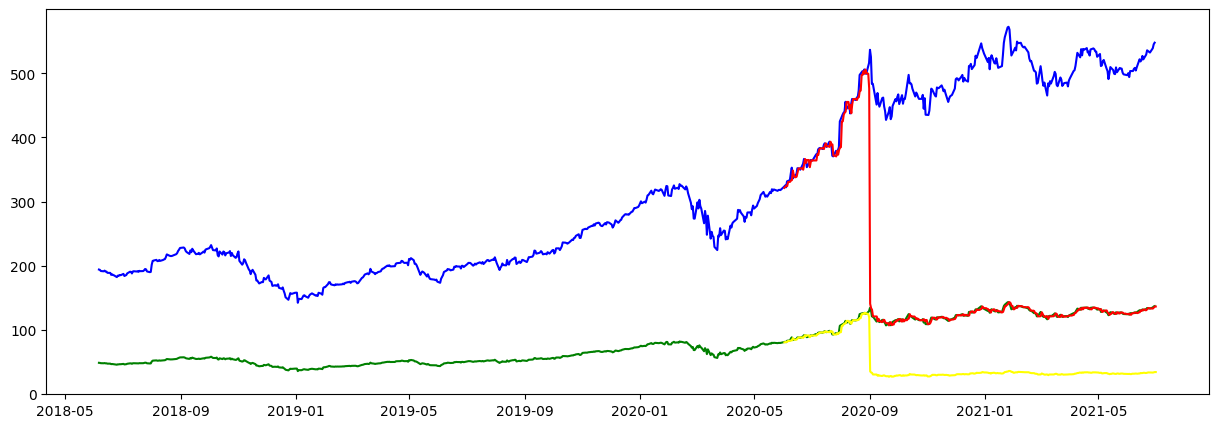

In [112]:
plt.figure(figsize=(15,5))
plt.plot(data['Close'], color='blue')
plt.plot(data['Close']/4, color='green')
plt.plot(lista_dfs[0]['close'],color='red')
plt.plot(lista_dfs[0]['close']/4,color='yellow')

In [113]:
#splits

<Axes: xlabel='trading_day'>

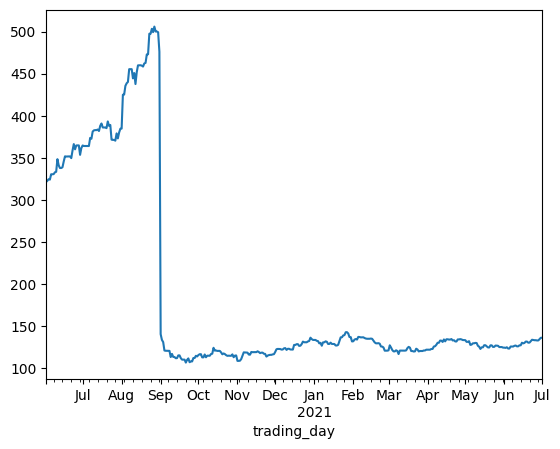

In [114]:
lista_dfs[0]['close'].plot()

In [115]:
def estimar_factor_por_tolerancia(ratio, tolerancia=0.05):
    posibles_factores = [2, 3, 4, 5, 6, 7, 8, 10]
    for f in posibles_factores:
        esperado = 1 / f
        if abs(ratio - esperado) <= tolerancia:
            return f
    return None  # No se detecta split si no hay coincidencia

In [116]:
import yfinance as yf
import pandas as pd

for i, df in enumerate(lista_dfs):
    # 2) Descargamos splits reales
    symbol = df['symbol'].iloc[0]
    splits = yf.Ticker(symbol).splits

    if splits.empty:
        lista_dfs[i] = df
        continue

    # 3) Normalizamos tz de splits para que coincida con df.index
    #    Si splits.index viene sin tz, lo localizamos; si viene con UTC, lo convertimos
    if splits.index.tz is None:
        splits.index = splits.index.tz_localize("America/New_York")
    else:
        splits.index = splits.index.tz_convert("America/New_York")

    # 4) Definimos el rango con tz NY
    fecha_min = pd.Timestamp("2020-06-02", tz="America/New_York")
    fecha_max = pd.Timestamp("2021-07-01", tz="America/New_York")

    # 5) Filtramos splits dentro de tu ventana
    splits = splits.loc[(splits.index >= fecha_min) & (splits.index <= fecha_max)]
    if splits.empty:
        lista_dfs[i] = df
        continue

    print(f"\n📅 Splits reales para {symbol} entre {fecha_min.date()} y {fecha_max.date()}:")
    print(splits)

    # 6) Ajustamos precios retrospectivamente
    for split_date, factor in splits.items():
        mask = df.index <= split_date
        for col in ['open','high','low','close']:
            if col in df.columns:
                df.loc[mask, col] /= factor

    lista_dfs[i] = df



📅 Splits reales para AAPL entre 2020-06-02 y 2021-07-01:
Date
2020-08-31 00:00:00-04:00    4.0
Name: Stock Splits, dtype: float64

📅 Splits reales para MRK entre 2020-06-02 y 2021-07-01:
Date
2021-06-03 00:00:00-04:00    1.048
Name: Stock Splits, dtype: float64


In [117]:
lista_dfs[0]

,open,high,low,last,close,volume,symbol
trading_day,,,,,,,
2020-06-02 00:00:00-04:00,80.299036,80.429401,80.164544,320.146389,80.340964,1.282583e+06,AAPL
2020-06-03 00:00:00-04:00,80.660285,80.753006,80.591060,NaN,80.703070,NaN,AAPL
2020-06-04 00:00:00-04:00,81.118685,81.265466,80.840037,322.893276,81.168741,1.420611e+05,AAPL
2020-06-05 00:00:00-04:00,81.178490,81.813270,81.085980,329.694286,81.035490,6.167777e+05,AAPL
2020-06-06 00:00:00-04:00,82.589435,82.684167,82.518482,331.500000,82.633810,3.359299e+07,AAPL
...,...,...,...,...,...,...,...
2021-06-27 00:00:00-04:00,133.130000,133.245000,133.130000,133.228333,133.110000,3.675000e+02,AAPL
2021-06-28 00:00:00-04:00,133.392902,135.122216,133.387414,134.891483,133.135535,6.475024e+05,AAPL
2021-06-29 00:00:00-04:00,134.787727,135.729331,134.690094,136.045759,134.783684,9.821496e+05,AAPL


In [118]:
data[data.index >= '2020-06-02']['Close']/4

Ticker,AAPL
Date,
2020-06-02,80.834999
2020-06-03,81.279999
2020-06-04,80.580002
2020-06-05,82.875000
2020-06-08,83.364998
...,...
2021-06-24,133.410004
2021-06-25,133.110001
2021-06-28,134.779999


In [119]:
lista_dfs[0]

,open,high,low,last,close,volume,symbol
trading_day,,,,,,,
2020-06-02 00:00:00-04:00,80.299036,80.429401,80.164544,320.146389,80.340964,1.282583e+06,AAPL
2020-06-03 00:00:00-04:00,80.660285,80.753006,80.591060,NaN,80.703070,NaN,AAPL
2020-06-04 00:00:00-04:00,81.118685,81.265466,80.840037,322.893276,81.168741,1.420611e+05,AAPL
2020-06-05 00:00:00-04:00,81.178490,81.813270,81.085980,329.694286,81.035490,6.167777e+05,AAPL
2020-06-06 00:00:00-04:00,82.589435,82.684167,82.518482,331.500000,82.633810,3.359299e+07,AAPL
...,...,...,...,...,...,...,...
2021-06-27 00:00:00-04:00,133.130000,133.245000,133.130000,133.228333,133.110000,3.675000e+02,AAPL
2021-06-28 00:00:00-04:00,133.392902,135.122216,133.387414,134.891483,133.135535,6.475024e+05,AAPL
2021-06-29 00:00:00-04:00,134.787727,135.729331,134.690094,136.045759,134.783684,9.821496e+05,AAPL


In [120]:
dfs_pct = []

for i, df in enumerate(lista_dfs):
    # 1️⃣ Quedarse solo con 'close' y 'symbol'
    df = df[["close", "symbol"]].copy()

    # 2️⃣ Calcular variación porcentual diaria
    df["rent"] = df["close"].pct_change()

    # 3️⃣ Eliminar la primera fila (NaN en pct_change)
    df = df.dropna(subset=["rent"])

    # 4️⃣ Guardar en la lista
    dfs_pct.append(df)

# 5️⃣ Unir todos los DataFrames en uno solo
df_final = pd.concat(dfs_pct)
df_final

,close,symbol,rent
trading_day,,,
2020-06-03 00:00:00-04:00,80.703070,AAPL,0.004507
2020-06-04 00:00:00-04:00,81.168741,AAPL,0.005770
2020-06-05 00:00:00-04:00,81.035490,AAPL,-0.001642
2020-06-06 00:00:00-04:00,82.633810,AAPL,0.019724
2020-06-07 00:00:00-04:00,82.633810,AAPL,0.000000
...,...,...,...
2021-06-27 00:00:00-04:00,395.570997,UNH,0.000000
2021-06-28 00:00:00-04:00,404.950000,UNH,0.023710
2021-06-29 00:00:00-04:00,401.460000,UNH,-0.008618


[*********************100%***********************]  1 of 1 completed


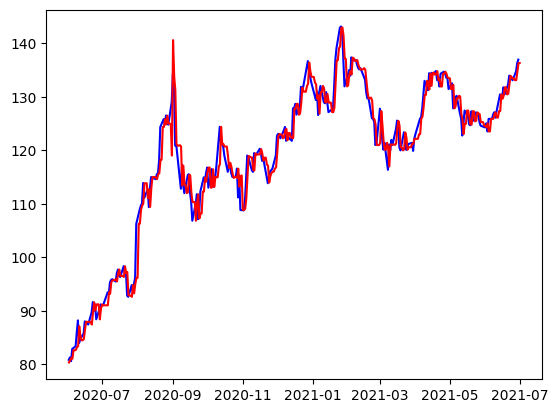

In [121]:
data = yf.download("AAPL", start="2020-06-02", end="2021-07-01", auto_adjust=False)
plt.plot(data['Close'], color='blue')
plt.plot(lista_dfs[0]['close'],color='red')

In [122]:
# Función para calcular rentabilidades anualizadas
def rtb_anualizada(tipo, n, p0, p1, dias_habiles):
    if tipo == 'd':
        r = (p1 - p0) / p0
        return ((1 + r) ** (dias_habiles / n)) - 1

    elif tipo == 'm':
        r = (p1 - p0) / p0
        return ((1 + r) ** (12 / n)) - 1

    elif tipo == 'y':
        r = (p1 - p0) / p0
        return ((1 + r) ** (1 / n)) - 1

    else:
        return("Por favor, introduzca 'd', 'm' o 'y' en el tipo")

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analisis_completo(df):
    """
    Recibe un DataFrame con:
      • Índice: trading_day (DatetimeIndex, sin duplicados)
      • Columnas: 
          - 'close'  → precio de cierre
          - 'rent'   → pct_change diario
          - 'symbol' → ticker (26 símbolos)

    Devuelve:
      1) df_riesgo_rent: DataFrame con Rentabilidad, Volatilidad y Sharpe_sim por símbolo
      2) corr: matriz de correlación de retornos
      3) precios_norm: evolución de precios normalizada a base 100
    """

    # 1️⃣ Primero, agrupamos por (fecha, símbolo) y tomamos el primer valor
    #    Esto elimina duplicados antes de pivotar
    grouped = df.groupby([df.index, 'symbol']).agg({
        'close': 'first',
        'rent':  'first'
    })

    # 2️⃣ Deshacemos el MultiIndex con unstack → columnas = símbolos
    precios = grouped['close'].unstack('symbol')
    retornos = grouped['rent'].unstack('symbol')

    # 3️⃣ Alineamos índices y eliminamos filas con NaN (días incompletos)
    common_index = precios.dropna(axis=0, how='any').index
    precios = precios.loc[common_index]
    retornos = retornos.loc[common_index]

    # 4️⃣ Cálculo de riesgo, rentabilidad media y Sharpe simulado
    volatilidad   = retornos.std()
    volatilidad_anual = volatilidad * np.sqrt(252)
    rentabilidad  = retornos.mean()
    df_riesgo_rent = pd.DataFrame({
        'Rentabilidad': rentabilidad,
        'Volatilidad': volatilidad,
        'Volatilidad_anual':  volatilidad_anual
    })
    df_riesgo_rent['Sharpe_sim'] = (
        df_riesgo_rent['Rentabilidad'] /
        df_riesgo_rent['Volatilidad']
    )

    # 5️⃣ Rentabilidad anualizada (tipo 'd', 252 días hábiles)
    dias_habiles_anuales = 252
    n_periodo = len(precios.index)
    rent_anual = {
        sym: rtb_anualizada('d',
                            n_periodo,
                            precios[sym].iloc[0],
                            precios[sym].iloc[-1],
                            dias_habiles_anuales)
        for sym in precios.columns
    }
    df_riesgo_rent['Rent_anualizada'] = pd.Series(rent_anual)

    df_riesgo_rent = df_riesgo_rent.sort_values('Sharpe_sim', ascending=False)

    print("📊 Ranking de activos (Sharpe simulado):")
    print(df_riesgo_rent)

    # 5️⃣ Gráfico Riesgo vs Rentabilidad
    plt.figure(figsize=(10, 6))
    plt.scatter(df_riesgo_rent['Volatilidad_anual'],
                df_riesgo_rent['Rent_anualizada'],
                s=80, color='teal')
    for sym in df_riesgo_rent.index:
        x = df_riesgo_rent.loc[sym, 'Volatilidad_anual']
        y = df_riesgo_rent.loc[sym, 'Rent_anualizada']
        plt.annotate(sym, (x, y), xytext=(5,5), textcoords="offset points")
    plt.xlabel("Volatilidad anualizada")
    plt.ylabel("Rentabilidad anualizada")
    plt.title("Riesgo vs Rentabilidad")
    plt.grid(alpha=0.3)
    plt.show()

    # 6️⃣ Matriz de correlación de retornos
    corr = retornos.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Matriz de correlación de retornos")
    plt.tight_layout()
    plt.show()

    # 7️⃣ Evolución temporal normalizada a base 100
    precios_norm = precios.div(precios.iloc[0]).mul(100)
    plt.figure(figsize=(12, 6))
    for sym in precios_norm.columns:
        plt.plot(precios_norm.index, precios_norm[sym], label=sym)
    plt.xlabel("Fecha")
    plt.ylabel("Índice base 100")
    plt.title("Evolución normalizada de precios")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_riesgo_rent, corr, precios_norm


📊 Ranking de activos (Sharpe simulado):
        Rentabilidad  Volatilidad  Volatilidad_anual  Sharpe_sim  \
symbol                                                             
GS          0.001688     0.015685           0.248998    0.107613   
CAT         0.001567     0.015415           0.244707    0.101653   
MSFT        0.001090     0.013282           0.210853    0.082072   
NKE         0.001262     0.015848           0.251586    0.079612   
AAPL        0.001521     0.019147           0.303951    0.079444   
JPM         0.001266     0.016236           0.257733    0.077976   
AXP         0.001534     0.019735           0.313289    0.077747   
DOW         0.001435     0.019586           0.310915    0.073276   
DIS         0.001105     0.016737           0.265699    0.066045   
HD          0.000702     0.011105           0.176291    0.063212   
TRV         0.000908     0.014655           0.232643    0.061942   
MCD         0.000567     0.009253           0.146891    0.061278   
UNH     

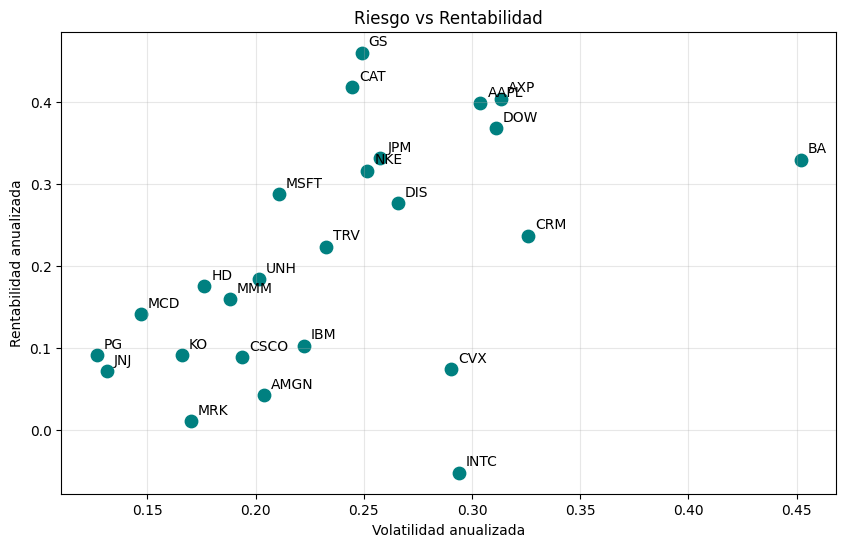

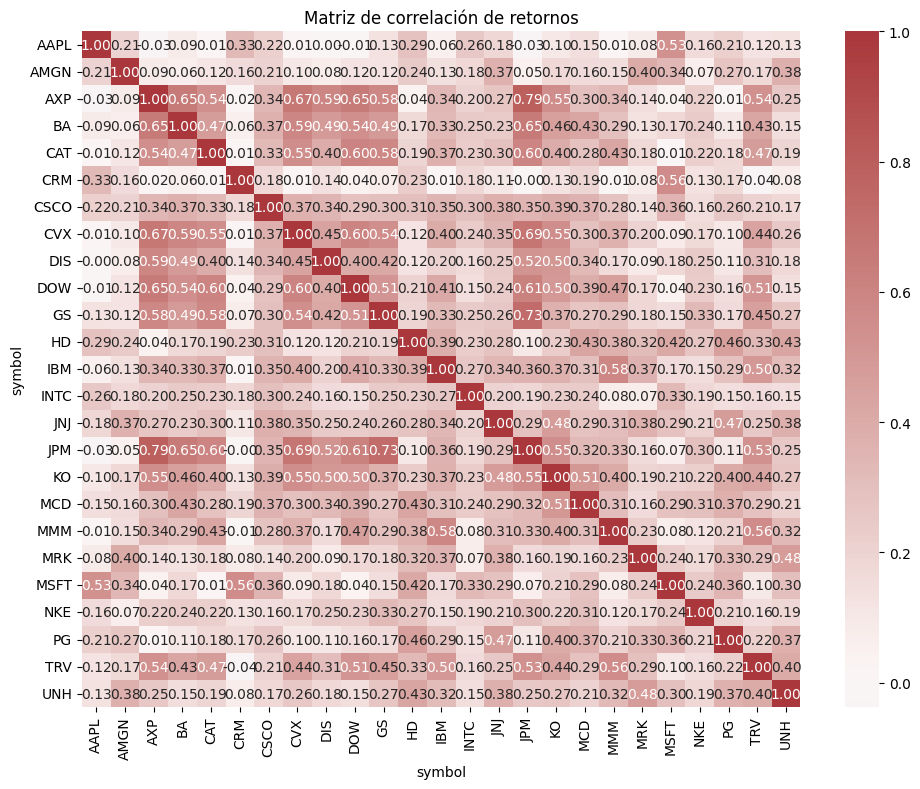

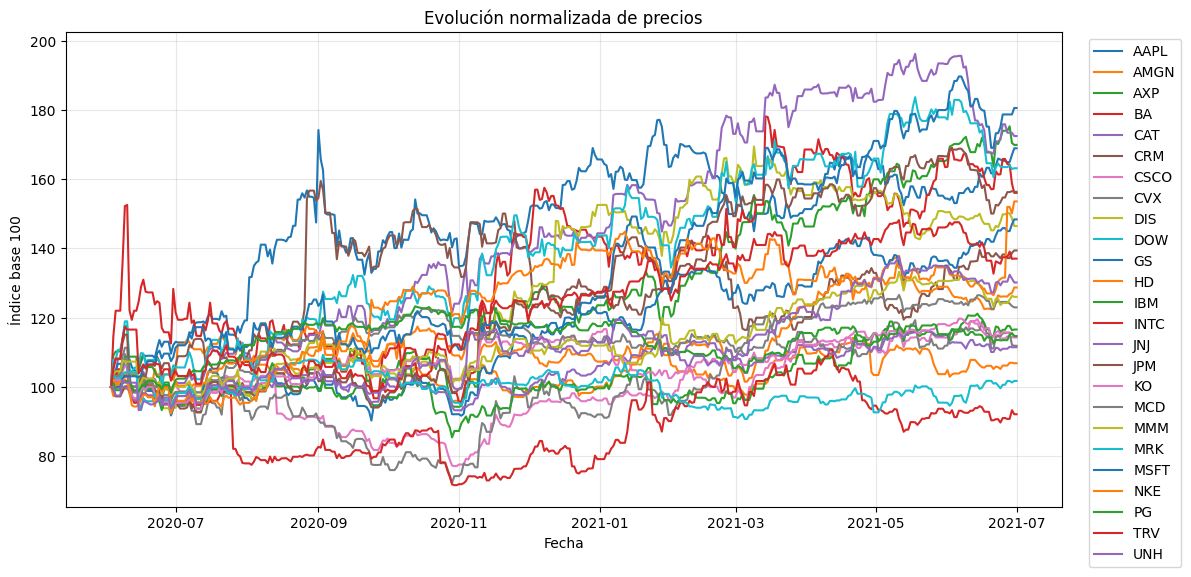

(        Rentabilidad  Volatilidad  Volatilidad_anual  Sharpe_sim  \
 symbol                                                             
 GS          0.001688     0.015685           0.248998    0.107613   
 CAT         0.001567     0.015415           0.244707    0.101653   
 MSFT        0.001090     0.013282           0.210853    0.082072   
 NKE         0.001262     0.015848           0.251586    0.079612   
 AAPL        0.001521     0.019147           0.303951    0.079444   
 JPM         0.001266     0.016236           0.257733    0.077976   
 AXP         0.001534     0.019735           0.313289    0.077747   
 DOW         0.001435     0.019586           0.310915    0.073276   
 DIS         0.001105     0.016737           0.265699    0.066045   
 HD          0.000702     0.011105           0.176291    0.063212   
 TRV         0.000908     0.014655           0.232643    0.061942   
 MCD         0.000567     0.009253           0.146891    0.061278   
 UNH         0.000749     0.012705

In [124]:
prueba = df_final.copy()
prueba = prueba[prueba['symbol'] != 'AAPL']

analisis_completo(df_final)

In [125]:
import seaborn as sns

def analisis_completo(datos_tickers):
    """
    Recibe un diccionario de DataFrames de yfinance y genera:
    1) DataFrame de riesgo vs rentabilidad + Sharpe simulado
    2) Matriz de correlación de precios
    3) Gráfico de evolución temporal normalizado a base 100
    """
    # --- DataFrame combinado de precios ---
    precios = pd.DataFrame()
    for t, df in datos_tickers.items():
        if 'Adj Close' in df.columns:
            precios[t] = df['Adj Close']
        elif 'Close' in df.columns:
            precios[t] = df['Close'] ##########################################################################
        else:
            print(f"Advertencia: no hay columna de precios para {t}")
    
    precios = precios.dropna()
    
    # --- Retornos diarios ---
    retornos = precios.pct_change().dropna()
    precios = precios.pct_change().dropna()
    
    # --- Riesgo, rentabilidad y Sharpe ---
    volatilidad = retornos.std()
    rentabilidad = retornos.mean()
    df_riesgo_rent = pd.DataFrame({
        'Rentabilidad': rentabilidad,
        'Volatilidad': volatilidad
    })
    df_riesgo_rent['Sharpe_sim'] = df_riesgo_rent['Rentabilidad'] / df_riesgo_rent['Volatilidad']
    df_riesgo_rent = df_riesgo_rent.sort_values(by='Sharpe_sim', ascending=False)
    
    print("Ranking de activos combinando riesgo y rentabilidad:")
    print(df_riesgo_rent)
    
    # --- Gráfico Riesgo vs Rentabilidad ---
    plt.figure(figsize=(12,6))
    plt.scatter(df_riesgo_rent['Volatilidad'], df_riesgo_rent['Rentabilidad'], s=100, color='blue')
    for i, txt in enumerate(df_riesgo_rent.index):
        plt.annotate(txt, (df_riesgo_rent['Volatilidad'][i], df_riesgo_rent['Rentabilidad'][i]))
    plt.xlabel("Volatilidad (Riesgo)")
    plt.ylabel("Rentabilidad media diaria")
    plt.title("Riesgo vs Rentabilidad Dow Jones")
    plt.grid(True)
    plt.show()
    
    # --- Matriz de correlación ---
    corr = precios.corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Matriz de correlación de precios")
    plt.tight_layout()
    plt.show()
    
    # --- Evolución temporal normalizada a base 100 ---
    precios_norm = precios / precios.iloc[0] * 100
    plt.figure(figsize=(14,7))
    for t in precios_norm.columns:
        plt.plot(precios_norm.index, precios_norm[t], label=t)
    plt.xlabel("Fecha")
    plt.ylabel("Índice Base 100")
    plt.title("Evolución temporal de todos los activos")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return df_riesgo_rent, corr, precios_norm

